Data du rheometre du Y16SE8 a 1mM:
- 08/01/2025
- 13/01/2025
- 16/01/2025
- 28/01/2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import os
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

π = np.pi
def fmmGp(ω, V, G, α, β):
    '''Elastic modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.cos(π*α/2) + Vo**2 * Go * np.cos(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmGpp(ω, V, G, α, β):
    '''Viscous modulus of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go**2 * Vo * np.sin(π*α/2) + Vo**2 * Go * np.sin(π*β/2)
    )/(
        Vo**2 + Go**2 + 2*Vo*Go*np.cos(π*(α-β)/2)
    )

def fmmtandelta(ω, V, G, α, β):
    '''Loss tangent of the Fractional Maxwell Model'''
    Go = G*ω**β
    Vo = V*ω**α
    return (
        Go * np.sin(π*α/2) + Vo * np.sin(π*β/2)
    )/(
        Go * np.cos(π*α/2) + Vo * np.cos(π*β/2)
    )

def mmtandelta(ω, k, τ):
    '''Loss tangent of the Maxwell Model'''
    return 1/(τ * ω)
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )

# sample 08/01/2025

Text(0.5, 1.0, 'after annealing 90C, 10C/min')

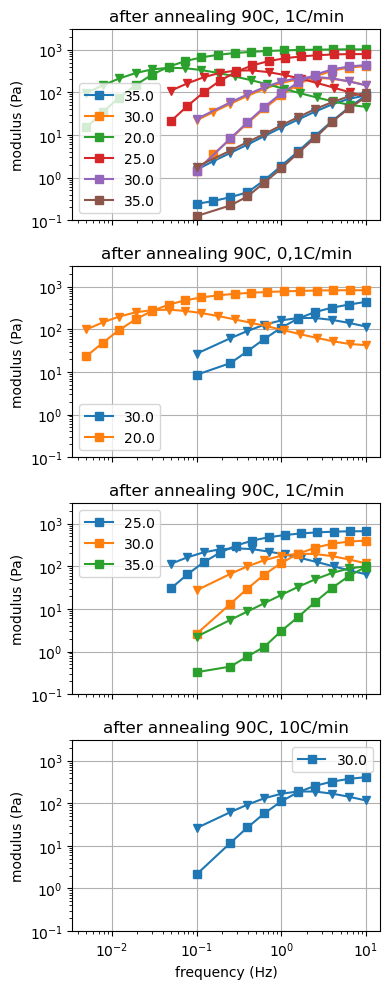

In [38]:
os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250108-2")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

def diff_function(x):
    return f_Gp(x) - f_Gpp(x)

def get_moduli(file):
    filename = f'Y8-FS-{file}.tsv'
    data = np.loadtxt(filename, skiprows=2, delimiter='\t')
    Temp = data[0,5]
    freq, Gp, Gpp = np.transpose(data[:,2:5])
    mask = (Gp != 0) & (Gpp != 0)
    freq, Gp, Gpp = freq[mask], Gp[mask], Gpp[mask]
    return Temp, freq, Gp, Gpp

def plot_moduli(n, ax, colors=colors):
    c = 0
    lines = []
    for i in n:
        T, freq, Gp, Gpp = get_moduli(i)
        line, = ax.plot(freq, Gp, marker='s', color=colors[c%len(n)], linestyle='-', label=T)
        ax.plot(freq, Gpp, marker='v', color=line.get_color(), linestyle='-')
        lines.append(line)
        c += 1
    return lines

## frequency sweeps at different T
fig1, ax1 = plt.subplots(4,1, figsize=(4,10), layout='tight', sharex=True)

n = [1,2,3,4,5,6] # normal annealing to 90C then back at -1C/min
plot_moduli(n, ax1[0])

n = [7, 8] # annealing 90C then back at -0.1C/min
plot_moduli(n, ax1[1])

n = [9, 10, 11] # no annealing but go to T at +1C/min
plot_moduli(n, ax1[2])

n = [12] # annealing 90C back at -10C/min
plot_moduli(n, ax1[3])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend()
    ax.grid()
    ax.set_ylim(0.1,3e3)
ax1[3].set_xlabel('frequency (Hz)')
ax1[0].set_title('after annealing 90C, 1C/min')
ax1[1].set_title('after annealing 90C, 0,1C/min')
ax1[2].set_title('after annealing 90C, 1C/min')
ax1[3].set_title('after annealing 90C, 10C/min')

Text(0, 0.5, 'fc (Hz)')

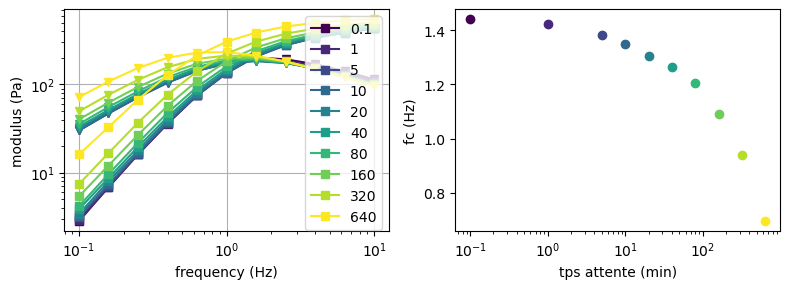

In [47]:
# test temps d attente
fig2, ax2 = plt.subplots(1,2, figsize=(8,3), layout='tight')

n = list(range(13,23))
labels = [0.1, 1, 5, 10, 20, 40, 80, 160, 320, 640]#, 1000]
gradient = plt.cm.viridis(np.linspace(0, 1, len(n)))
lines = plot_moduli(n, ax2[0], gradient)
ax2[0].set_xscale('log')
ax2[0].set_yscale('log')
ax2[0].set_ylabel('modulus (Pa)')
ax2[0].set_xlabel('frequency (Hz)')
ax2[0].legend(lines, labels)
ax2[0].grid()

c = 0
for i in n:
    T, freq, Gp, Gpp = get_moduli(i)
    f_Gp = interp1d(freq, Gp, kind='cubic', fill_value="extrapolate")
    f_Gpp = interp1d(freq, Gpp, kind='cubic', fill_value="extrapolate")
    intersection = root_scalar(diff_function, bracket=[min(freq), max(freq)], method='brentq')
    freq_intersection = intersection.root
    Gp_intersection = f_Gp(freq_intersection)
    Gpp_intersection = f_Gpp(freq_intersection) 
    ax2[1].plot(labels[c],freq_intersection, marker='o', color=gradient[c])
    c += 1
ax2[1].set_xscale('log')
ax2[1].set_xlabel('tps attente (min)')
ax2[1].set_ylabel('fc (Hz)')

# sample 13/01/2025

Text(0.5, 1.0, 'after annealing 90C, with 5min wait')

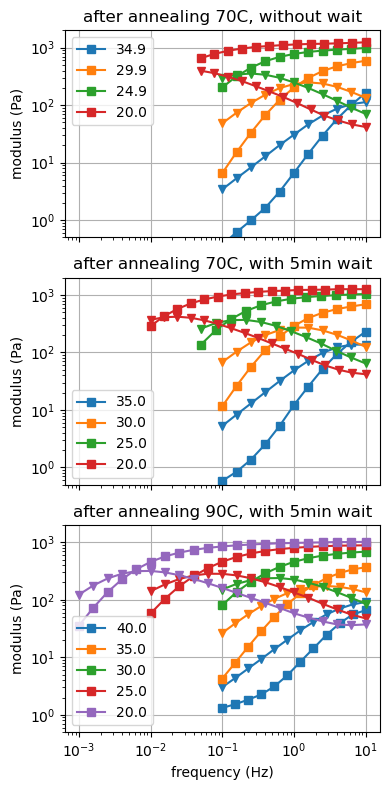

In [52]:
os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250113")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

## effect of annealing protocols on frequency sweeps
fig1, ax1 = plt.subplots(3,1, figsize=(4,8), layout='tight', sharex=True)

n = [1,2,3,4] # annealing to 70C then measure without waiting at desired T
plot_moduli(n, ax1[0])

n = [5,6,7,8] # annealing to 70C then measure after waiting 5min at desired T
plot_moduli(n, ax1[1])

n = [9,10,11,12,13] # annealing to 90C then measure after waiting 5min at desired T
plot_moduli(n, ax1[2])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend()
    ax.grid()
    ax.set_ylim(5e-1,2e3)
ax1[2].set_xlabel('frequency (Hz)')
ax1[0].set_title('after annealing 70C, without wait')
ax1[1].set_title('after annealing 70C, with 5min wait')
ax1[2].set_title('after annealing 90C, with 5min wait')

Text(0.5, 1.0, 'control curves')

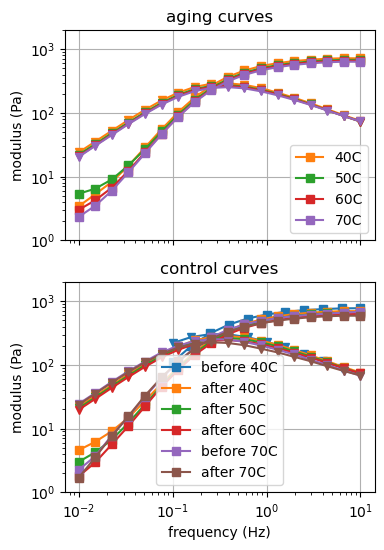

In [59]:
# aging test
fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [15,17,18,19]
lines1 = plot_moduli(n, ax2[0], colors[1:])
labels1 = ['40C', '50C', '60C', '70C']

n = [14,16,18,20,21,23]
lines2 = plot_moduli(n, ax2[1])
labels2 = ['before 40C', 'after 40C', 'after 50C', 'after 60C', 'before 70C', 'after 70C']

for ax in ax2:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.grid()
    ax.set_ylim(1,2e3)
ax2[1].set_xlabel('frequency (Hz)')
ax2[0].legend(lines1, labels1)
ax2[1].legend(lines2, labels2)
ax2[0].set_title('aging curves')
ax2[1].set_title('control curves')

# sample 16/01/2025

Text(0.5, 1.0, 'after annealing 90C, with 5min wait, control curve')

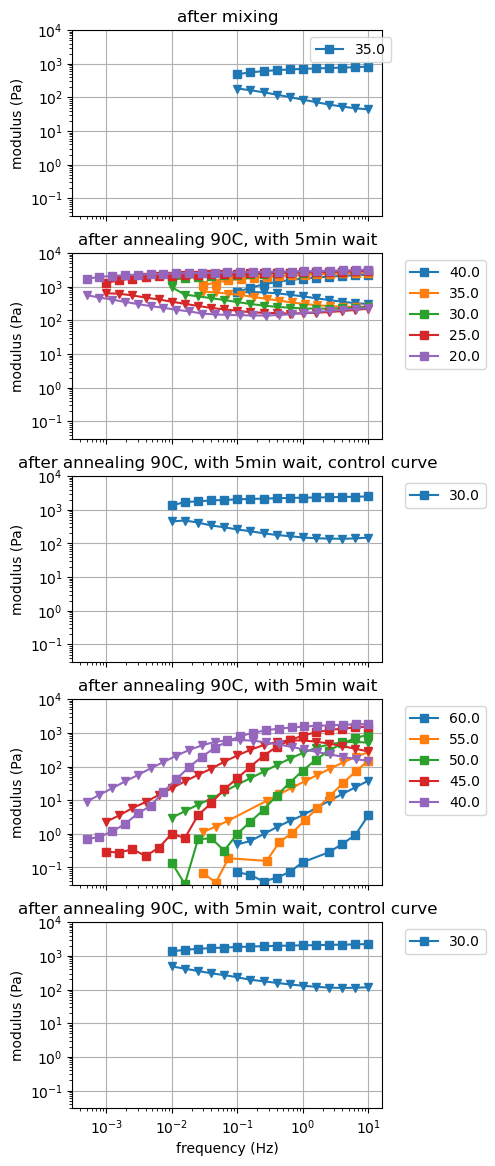

In [64]:
os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250116")
fig1, ax1 = plt.subplots(5,1, figsize=(4,14), sharex=True)

n = [1]
plot_moduli(n, ax1[0])

n = list(range(2,7))
plot_moduli(n, ax1[1])

n = [7]
plot_moduli(n, ax1[2])

n = list(range(8,13))
plot_moduli(n, ax1[3])

n = [13]
plot_moduli(n, ax1[4])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend(bbox_to_anchor=(1.05, 1))
    ax.grid()
    ax.set_ylim(3e-2,1e4)
ax1[4].set_xlabel('frequency (Hz)')
ax1[0].set_title('after mixing')
ax1[1].set_title('after annealing 90C, with 5min wait')
ax1[2].set_title('after annealing 90C, with 5min wait, control curve')
ax1[3].set_title('after annealing 90C, with 5min wait')
ax1[4].set_title('after annealing 90C, with 5min wait, control curve')

# sample 28/01/2025

Text(0.5, 1.0, 'after annealing 90C, with 5min wait')

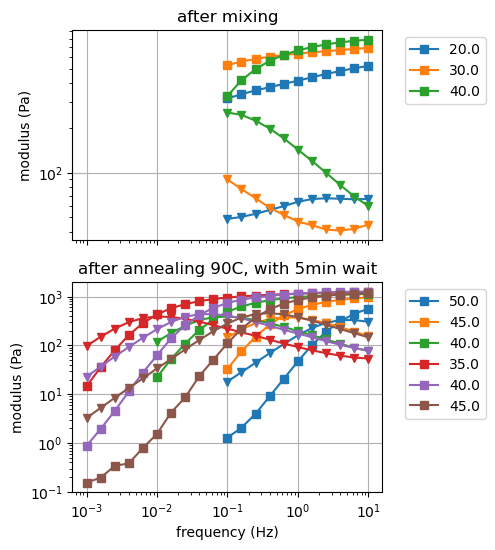

In [66]:
def get_moduli2(file):
    filename = f'Y8-FS-{file}.tsv'
    data = np.loadtxt(filename, skiprows=2, delimiter='\t')
    Temp = data[0,6]
    freq, Gp, Gpp = np.transpose(data[:,2:5])
    mask = (Gp != 0) & (Gpp != 0)
    freq, Gp, Gpp = freq[mask], Gp[mask], Gpp[mask]
    return Temp, freq, Gp, Gpp

def plot_moduli2(n, ax, colors=colors):
    c = 0
    lines = []
    for i in n:
        T, freq, Gp, Gpp = get_moduli2(i)
        line, = ax.plot(freq, Gp, marker='s', color=colors[c%len(n)], linestyle='-', label=T)
        ax.plot(freq, Gpp, marker='v', color=line.get_color(), linestyle='-')
        lines.append(line)
        c += 1
    return lines

os.chdir(r"C:\Users\ajiye\Documents\Rheometre\20250128")
fig1, ax1 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [1,2,3]
plot_moduli2(n, ax1[0])

n = list(range(4,10))
plot_moduli2(n, ax1[1])

for ax in ax1:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('modulus (Pa)')
    ax.legend(bbox_to_anchor=(1.05, 1))
    ax.grid()
    # ax.set_ylim(3e-2,1e4)
ax1[1].set_xlabel('frequency (Hz)')
ax1[0].set_title('after mixing')
ax1[1].set_title('after annealing 90C, with 5min wait')

<>:14: SyntaxWarning: invalid escape sequence '\%'
<>:14: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ajiye\AppData\Local\Temp\ipykernel_65748\2125100044.py:14: SyntaxWarning: invalid escape sequence '\%'
  line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')


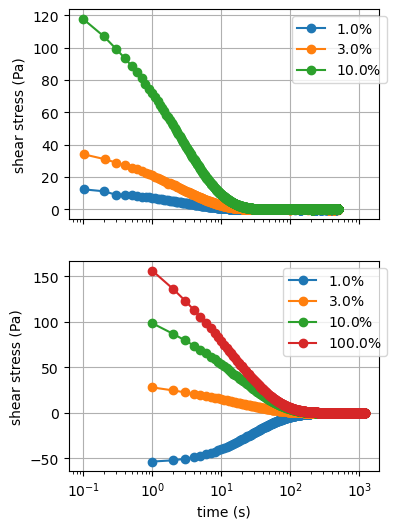

In [90]:
def get_strain(file):
    filename = f'Y8-strain-{file}.tsv'
    data = np.genfromtxt(filename, skip_header=2, delimiter='\t', usecols=(0,5,7,8), dtype=float)
    Temp = data[0,1]
    time = data[:,0]
    gamma, tau = np.transpose(data[:,2:])
    return Temp, time, gamma, tau

def plot_strain(n, ax):
    c = 0
    lines = []
    for i in n:
        T, time, gamma, tau = get_strain(i)
        line, = ax.plot(time, tau, marker='o', color=colors[c%len(n)], linestyle='-', label=f'{gamma[0]}$\%$')
        lines.append(line)
        c += 1
    return lines

fig2, ax2 = plt.subplots(2,1, figsize=(4,6), sharex=True)

n = [2,4,6]
plot_strain(n, ax2[0])

n = [8,10,12,14]
plot_strain(n, ax2[1])

ax2[1].set_xscale('log')
ax2[1].set_xlabel('time (s)')
for ax in ax2:
    ax.set_ylabel('shear stress (Pa)')
    ax.grid()
    ax.legend(bbox_to_anchor=(1.05,1))
